# Question 1: Comparison of the income and illegal desposed waste in Zürich

Author: Tim Berger 
Date: 20.5.2026

#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or springs or light bulbs. 
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).
As the trashbags to officially despose trash are expensive, and desposing special waste is only free up to 20 kg, this analysis aims to compare the number of reports in Züri wie neu in the "Abfall/ Sammelstelle" category per neighbourhood with the mean taxable income per neighbourhood.

#### Research Question: 
Is proper special waste deposition in Zürich too expensive, does the the number of reports in Züri wie neu in the "Abfall/ Sammelstelle" category per neighbourhood correlate with the mean taxable income per neighbourhood?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository of this project.


### Import Required Packages and Scripts

In [40]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

import notebook_utils

### Access and load data via API (züri wie neu, neighbourhoods, income)

In [ ]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()
population_df_raw = notebook_utils.import_population_data()
income_df_raw = notebook_utils.import_income_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull


## Clean and Filter the Data

- filter income for the newest year and create a mean for the 3 steuertarife

In [ ]:
# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the data of the newest year (always current year minus 3)
income_df = income_df_raw[income_df_raw["StichtagDatJahr"] == str(current_year -3)].copy()


In [ ]:
## create a mean for the 3 steuer tarife

#clean the data (drop na, convert to float)
income_df.dropna(subset=["SteuerEinkommen_p50"])
income_df["SteuerEinkommen_p50"] = income_df["SteuerEinkommen_p50"].astype(float)

#group by neigbourhoods and compute the mean income (of the 3 steuertarife) for each income
steuertarife_grouped_by_neighbourhoods = income_df.groupby("QuarLang", as_index=False)
income_df = steuertarife_grouped_by_neighbourhoods[["SteuerEinkommen_p50"]].mean()

#rename the columns
income_df = income_df.rename(columns={"SteuerEinkommen_p50": "mean_income", "QuarLang": "qname"})

- clean züri wie neu data

In [ ]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]

- clean neighbourhood data

In [ ]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

- clean population data

In [ ]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

#convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

#rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})

<class 'pandas.DataFrame'>
Index: 34 entries, 0 to 2729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       34 non-null     str  
 1   population  34 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


## Join and Merge Data together

In [53]:

#join the trash points to the neighbourhoods
waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")

#count the number of waste per neighbourhood and safe it as a series waste_income_df
waste_income_df = waste_with_neighbourhoods_df[["qname"]].value_counts()

#rename the series
waste_income_df = waste_income_df.rename("count_waste")

In [54]:
# merge the income to the waste_income_df

waste_income_df = pd.merge(left=waste_income_df, 
                                        right=income_df,
                                        left_on="qname",
                                        right_on="qname")
waste_income_df = waste_income_df.sort_values(by="mean_income", ascending=True)
waste_income_df = waste_income_df.set_index("qname")

waste_income_df.info()

<class 'pandas.DataFrame'>
Index: 34 entries, Hirzenbach to Fluntern
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   count_waste  34 non-null     int64  
 1   mean_income  34 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [55]:
# merge the population to the waste_income_df

waste_income_df = pd.merge(left=waste_income_df, 
                                        right=population_df,
                                        left_index=True,
                                        right_on="qname")
waste_income_df.info()


<class 'pandas.DataFrame'>
Index: 34 entries, 2729 to 1427
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   count_waste  34 non-null     int64  
 1   mean_income  34 non-null     float64
 2   qname        34 non-null     str    
 3   population   34 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 1.6 KB


In [58]:
#merge the neighbourhood geometry to the waste_income_df
waste_income_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_income_df,
                                        left_on="qname",
                                        right_on="qname")

# normalize the waste per 100 person
waste_income_gdf["waste_density"] = 100* waste_income_gdf["count_waste"]/waste_income_gdf["population"] 

#sort values my mean income
waste_income_gdf = waste_income_gdf.sort_values(by="mean_income", ascending=True)

#set the index to the neighbourhood name
waste_income_gdf = waste_income_gdf.set_index("qname")

waste_income_gdf.head(5)


,qnr,geometry,count_waste,mean_income,population,waste_density
qname,,,,,,
Hirzenbach,123,"POLYGON ((2685538.292 1250614.334, 2685539.478...",306,48.500000,12597,2.429150
Schwamendingen-Mitte,122,"POLYGON ((2684161.492 1250427.041, 2684165.247...",401,49.183333,11383,3.522797
Hard,44,"POLYGON ((2679958.026 1249151.691, 2679977.851...",1636,49.200000,12817,12.764297
Saatlen,121,"POLYGON ((2684510.278 1251962.265, 2684542.496...",217,50.583333,8852,2.451423
Friesenberg,33,"POLYGON ((2678931.42 1245766.698, 2678940.152 ...",346,55.100000,11226,3.082131


## Plot Data


- create a barplot to see the distribution of the ilegal desposed trash and mean income in the neighbourhoods

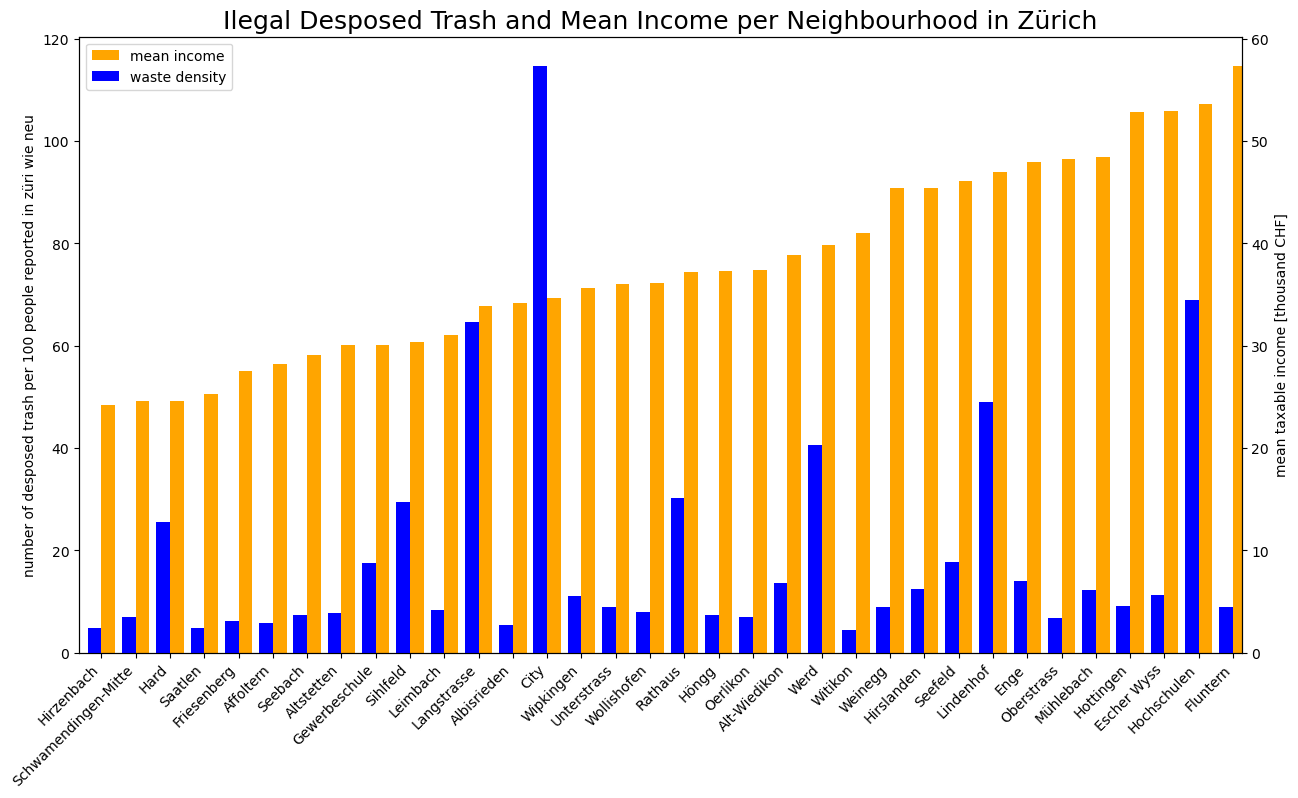

In [78]:
fig, ax1 = plt.subplots(figsize= (15,8))

#create a second y axis with the same x axis
ax2 = ax1.twinx()

#plot the income as a barplot
waste_income_gdf["mean_income"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               ylabel="number of desposed trash per 100 people reported in züri wie neu",
                               xlabel="", legend=False)

#set title
ax1.set_title("Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich", fontsize=18)

#plot the waste density as bars next to the income
waste_income_gdf["waste_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="mean taxable income [thousand CHF]", legend=False)

#rotate neighbourhood labels on the x axis
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")

#add a legend
handles_income, labels_income = ax1.get_legend_handles_labels()
handles_waste, labels_waste = ax2.get_legend_handles_labels()
ax2.legend(handles_income + handles_waste, ["mean income", "waste density"], loc="upper left")


plt.show()

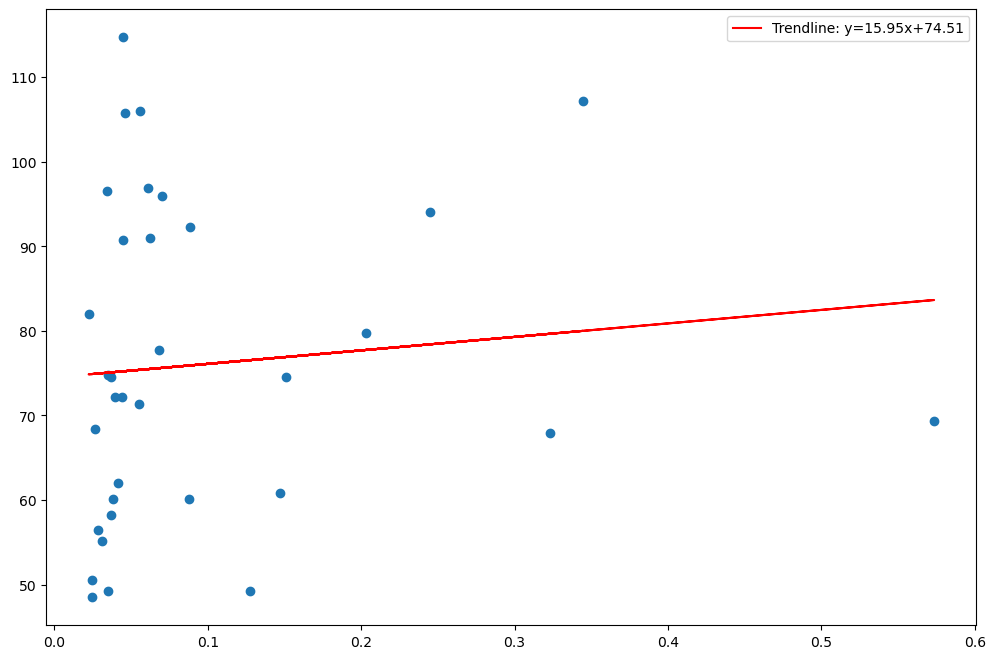

In [ ]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(waste_income_gdf["waste_density"], waste_income_gdf["mean_income"])
m, b = np.polyfit(waste_income_gdf["waste_density"], waste_income_gdf["mean_income"], 1)
x= waste_income_gdf["waste_density"]
y= waste_income_gdf["mean_income"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


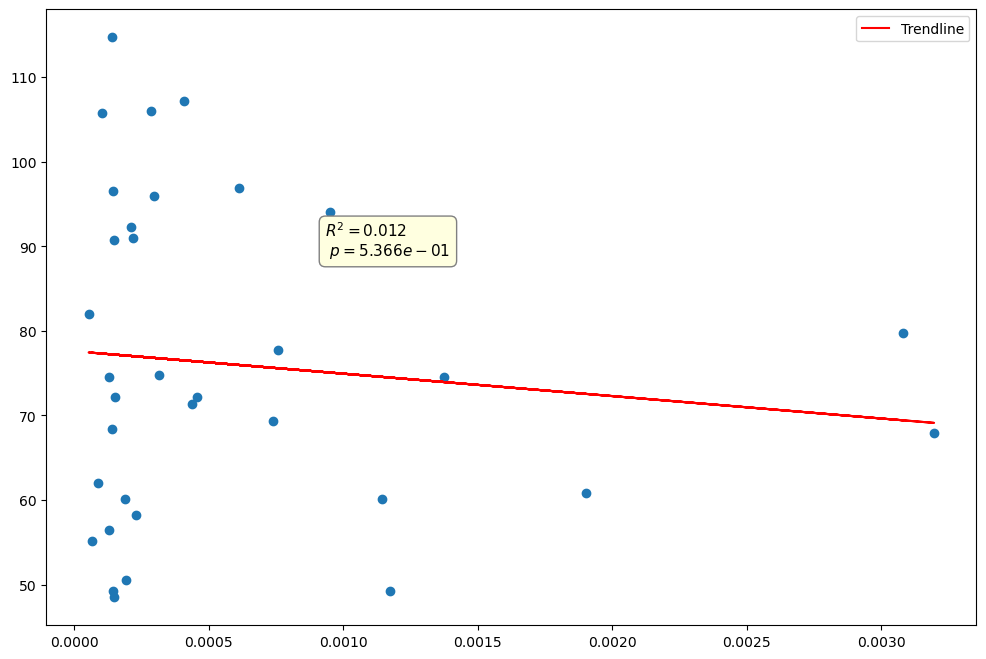

In [12]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= neighbourhoods_with_waste_income_gdf["waste_density"]
y= neighbourhoods_with_waste_income_gdf["mean_income"]

ax3.scatter(x,y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='red',label='Trendline')


ax3.annotate(
    f'$R^2 = {r_squared:.3f}$  \n $p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()